<a href="https://colab.research.google.com/github/martaaa-16/Pembelajaran_Mesin_2026/blob/main/T4_244107020205_Marta_Prama_Daniswara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum 1**
## **K Means**

In [ ]:
# Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [68]:
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


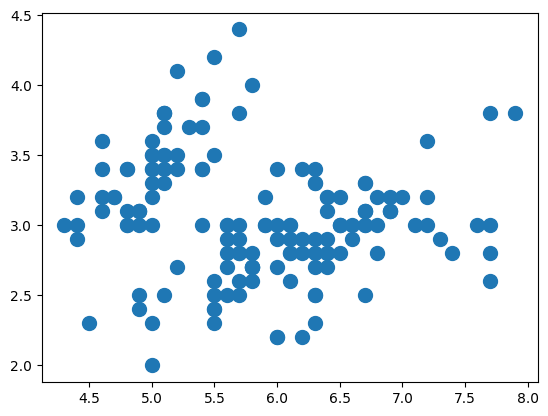

In [ ]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [ ]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

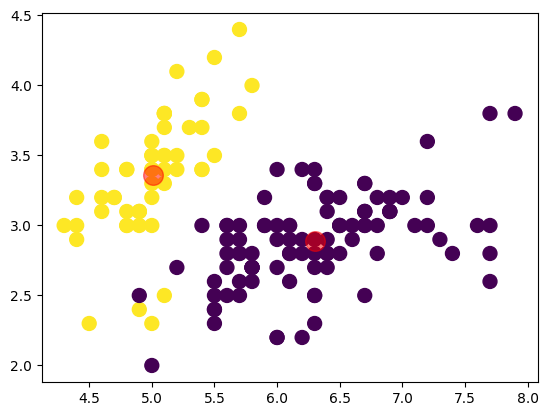

In [ ]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [ ]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


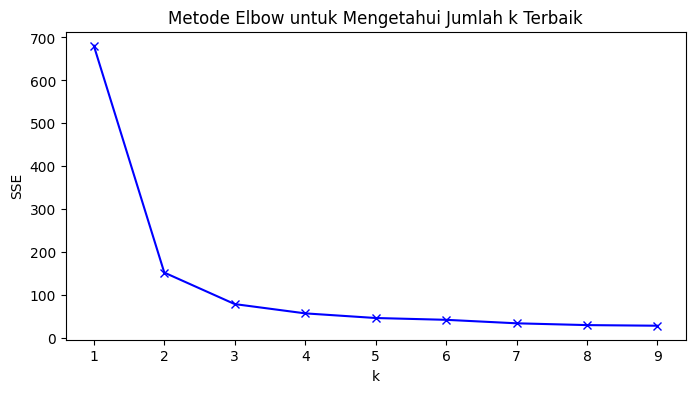

In [ ]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [ ]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.34540931571815
k=5; SSE=46.535582051282034
k=6; SSE=42.32839896214897
k=7; SSE=34.18920546865629
k=8; SSE=30.027336421037223
k=9; SSE=28.571289882780153


# **Praktikum 2**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## **Pengantar k-Means**

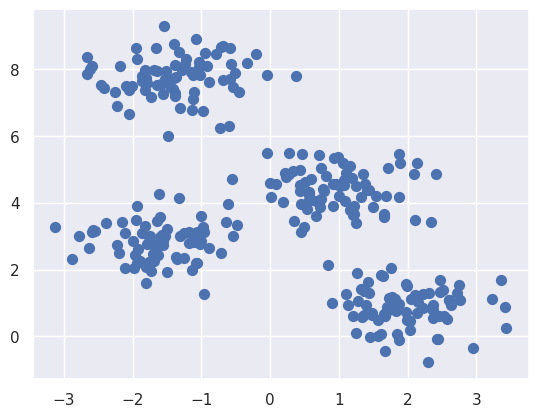

In [ ]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

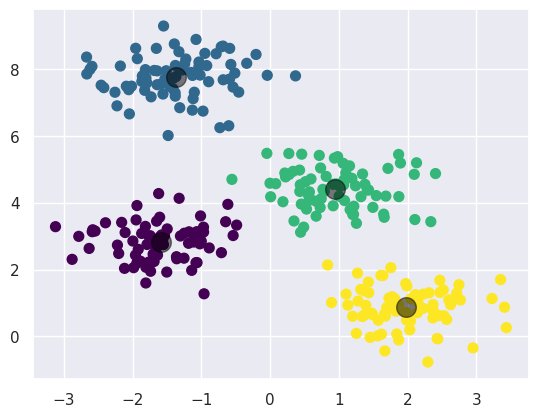

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

## **Algoritma Expectation-Maximization**

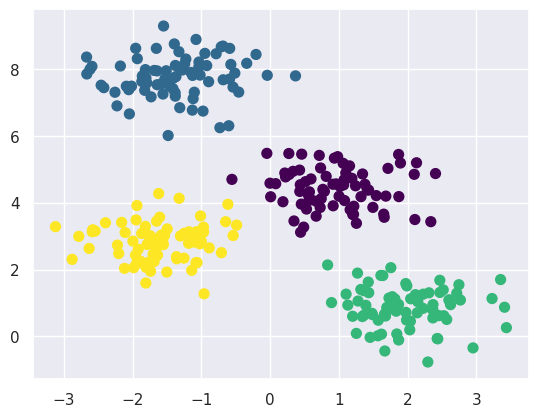

In [ ]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

#### **Perubahan random**

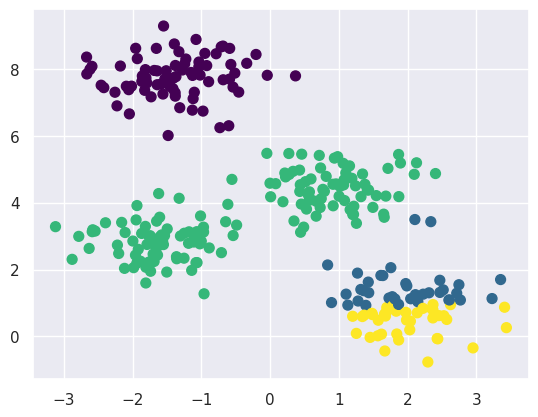

In [ ]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

#### **Optimalisasi Jumlah Klaster**

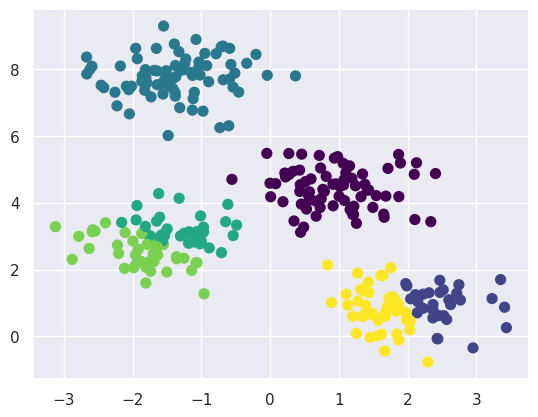

In [ ]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

#### **Batas Klaster yang Tidak Selalu Linier**

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

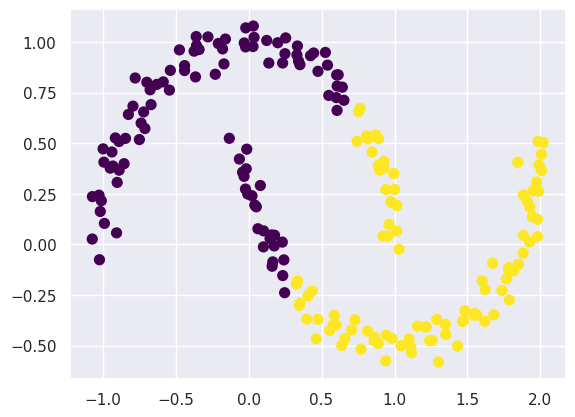

In [ ]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


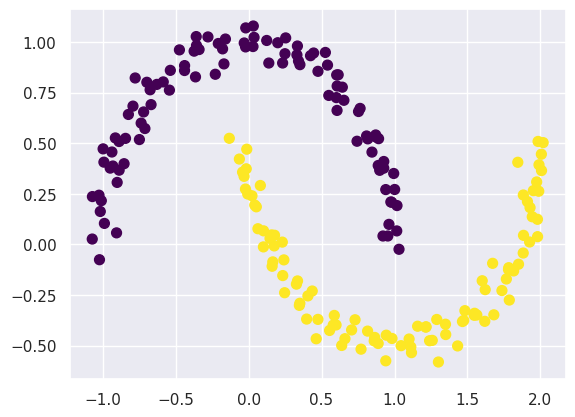

In [ ]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

## **Contoh Kasus 1: Karakter Angka**

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [ ]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

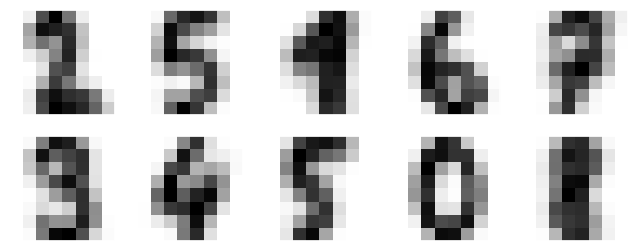

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [ ]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

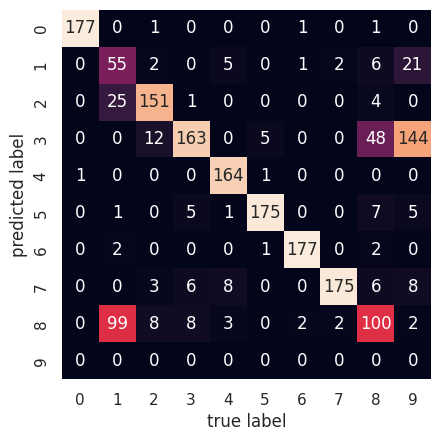

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [ ]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

## **Studi Kasus 2: Kompresi Citra**

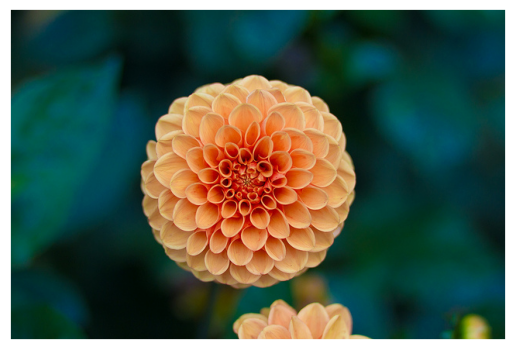

In [ ]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [ ]:
flower.shape

(427, 640, 3)

In [ ]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [ ]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

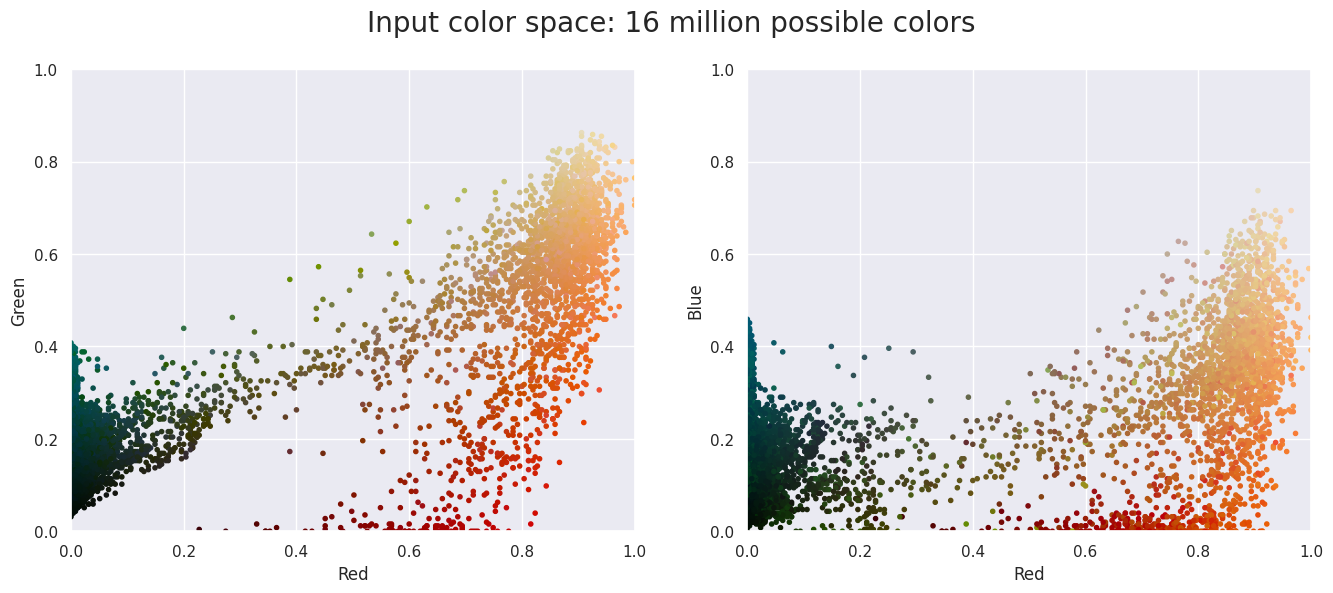

In [ ]:
plot_pixels(data, title='Input color space: 16 million possible colors')

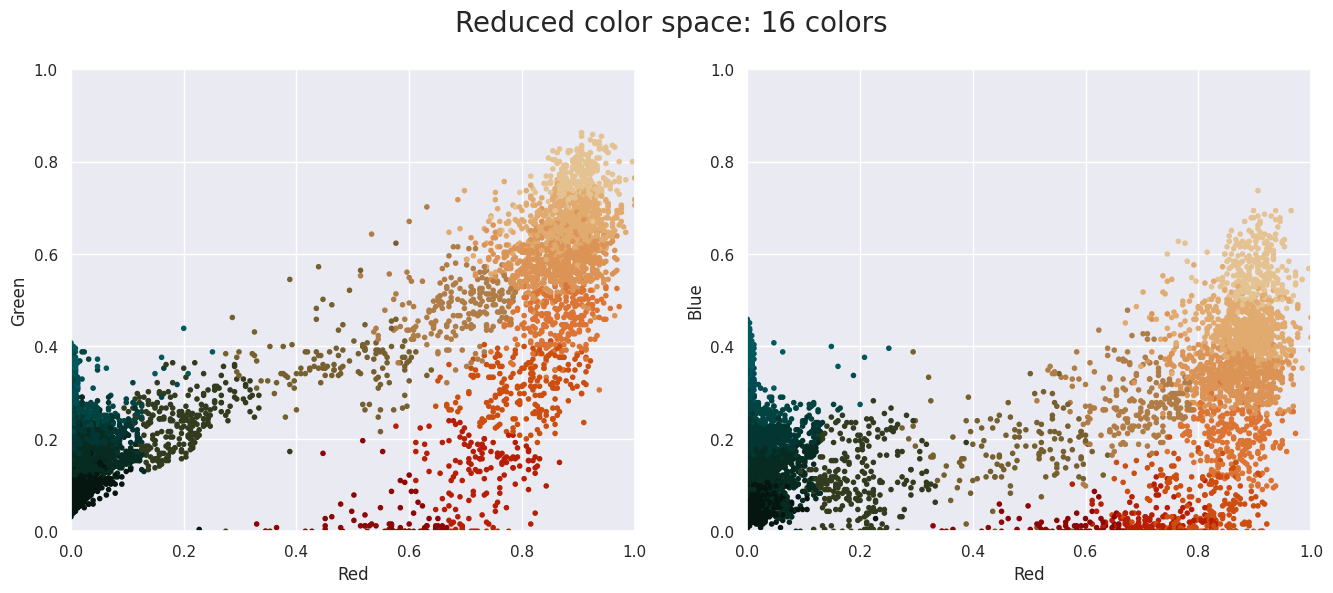

In [ ]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

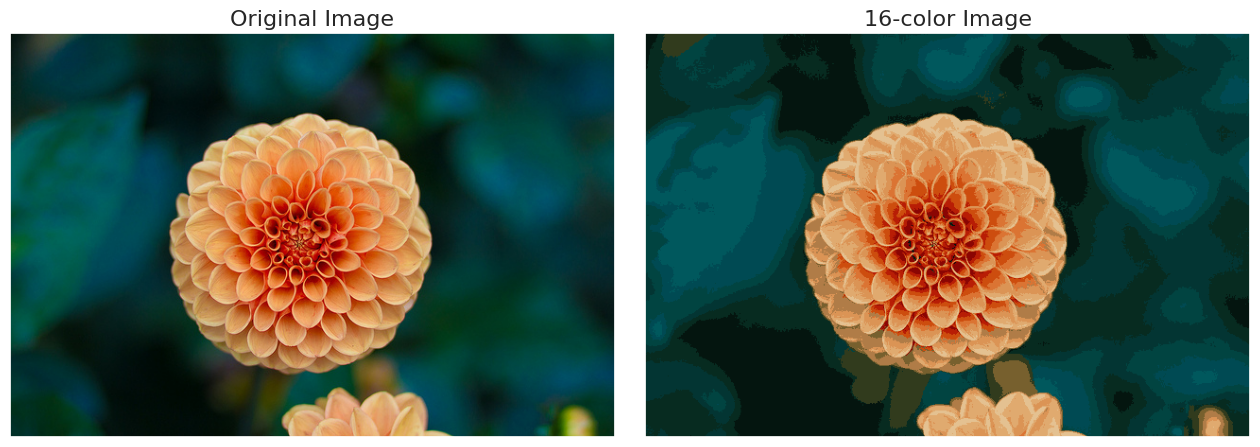

In [ ]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# **Praktikum 3**
## **Pembuatan Dataset Sintetis**

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

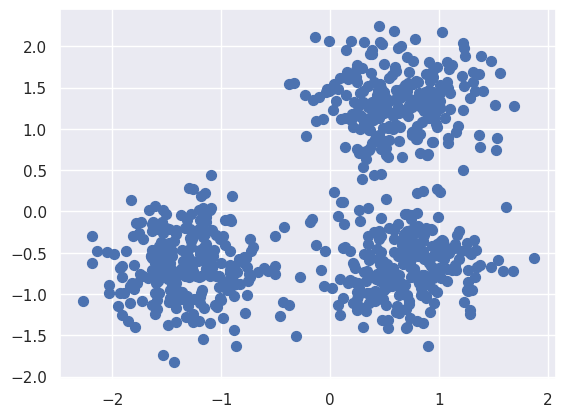

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], s = 50)

## **Compute DBSCAN**

In [ ]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


## **Evaluasi Kualitas Klasterisasi**

In [ ]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


## **Visualisasi Hasil Klasterisasi**

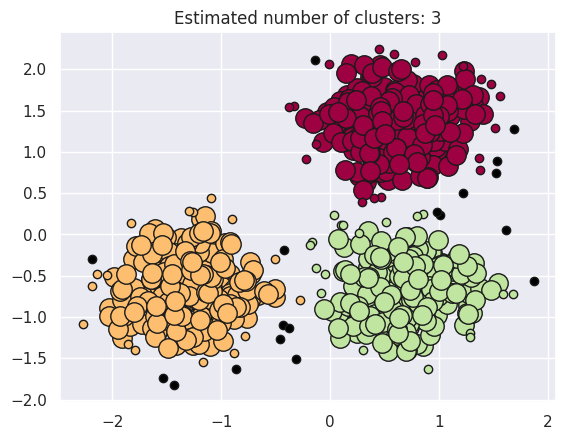

In [ ]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Plot core samples
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    # Plot non-core samples (boundaries / noise)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# **Tugas Praktikum**
### **1. Tugas K-Means**
Buatlah sebuah model K-Means dengan ketentuan,
1. Gunakan data 'Mall_Customers.csv'
2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
3. Buatlah model K-Means dengan mempertimbangkan jumlah *k* yang terbaik.

### **2. Tugas DBSCAN**
1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).
5. Lakukan eksperimen:
- eps = 0.05, 0.1, 0.3, 0.5
- min_samples = 3, 10, 20
- Catat perubahan klaster, noise, dan kualitas evaluasi.

## **Jawaban Tugas K-Means**

#### **1. Gunakan data 'Mall_Customers.csv'**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Load Dataset
df_mall = pd.read_csv('Mall_Customers.csv')
display(df_mall.head())
print(df_mall.info())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


#### **2. Menentukan Fitur yang Tepat Untuk Melakukan Clustering**

**Fitur yang dipilih:**
1. Annual Income (k$) (Pendapatan Tahunan)
2. Spending Score (1-100) (Skor Pengeluaran)

**Alasan Penentuan Fitur:** Kedua fitur ini merupakan parameter yang paling objektif dan representatif untuk mengelompokkan perilaku belanja (shopping behavior) pelanggan. Kombinasi antara kemampuan finansial (pendapatan) dan kecenderungan pengeluaran (skor belanja) dapat memetakan segmentasi pasar secara akurat tanpa terpengaruh oleh bias demografis seperti usia atau jenis kelamin.

#### **3. Buat Model K-Means dengan Mempertimbangkan Jumlah *k* yang Terbaik**

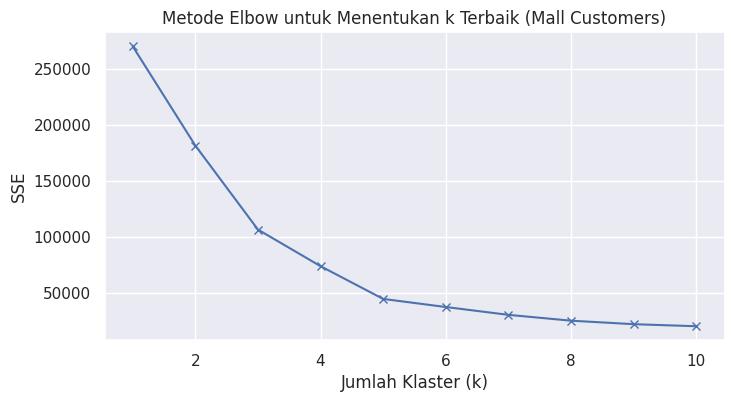

In [ ]:
# 1. Seleksi Fitur
X_mall = df_mall.iloc[:, [3, 4]].values  # Mengambil kolom 'Annual Income' dan 'Spending Score'

# 2. Menentukan jumlah k terbaik dengan Metode Elbow
sse_mall = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_mall)
    sse_mall.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, sse_mall, 'bx-')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('SSE')
plt.title('Metode Elbow untuk Menentukan k Terbaik (Mall Customers)')
plt.show()

### **Kesimpulan Metode Elbow:**
1. **Penurunan SSE yang Signifikan:** Berdasarkan grafik SSE di atas, terlihat penurunan nilai Error kuadrat (SSE) yang sangat tajam dari $k=1$ hingga $k=3$.
2. **Titik Siku (Elbow Point):** Penurunan mulai melandai secara konsisten setelah **$k=5$**. Titik di mana penurunan tajam ini berubah menjadi landai (membentuk pola menyerupai siku tangan) terjadi pada nilai **$k=5$**.
3. **Jumlah Klaster Optimal:** Setelah $k=5$, penambahan klaster baru tidak lagi memberikan penurunan SSE yang cukup signifikan (keuntungan pembagian klaster berkurang). Oleh karena itu, jumlah klaster terbaik dan paling optimal untuk segmentasi data *Mall Customers* ini adalah **$k = 5$**.

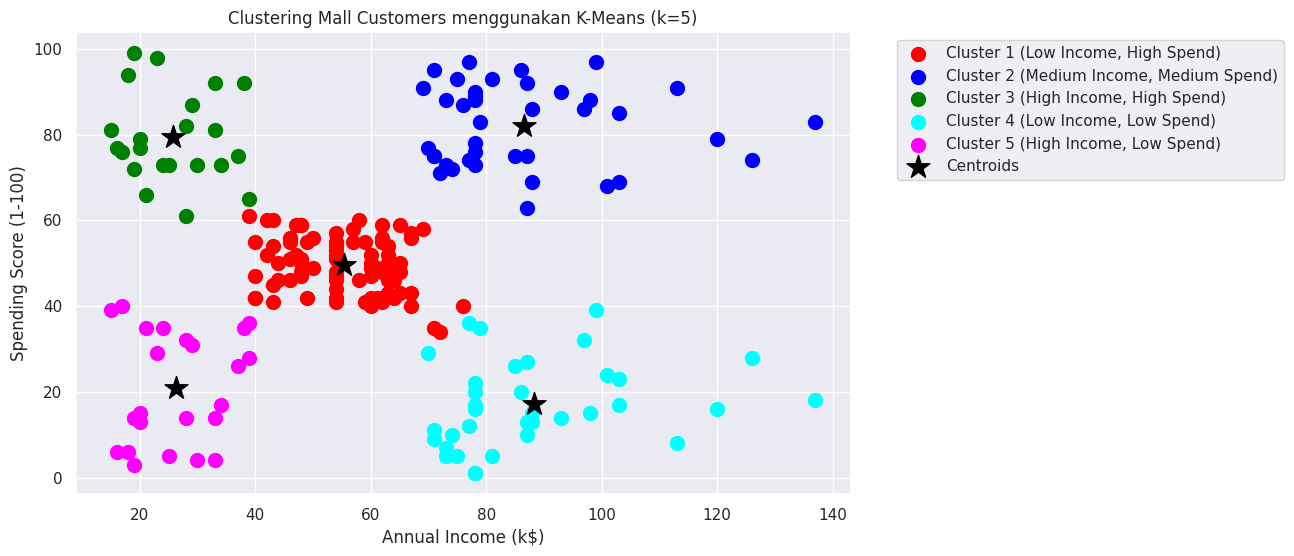

In [ ]:
# 4. Buat Model K-Means dengan k=5
kmeans_mall = KMeans(n_clusters=5, random_state=42, n_init=10)
y_mall_kmeans = kmeans_mall.fit_predict(X_mall)

# 5. Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1 (Low Income, High Spend)',
          'Cluster 2 (Medium Income, Medium Spend)',
          'Cluster 3 (High Income, High Spend)',
          'Cluster 4 (Low Income, Low Spend)',
          'Cluster 5 (High Income, Low Spend)']

for i in range(5):
    plt.scatter(X_mall[y_mall_kmeans == i, 0], X_mall[y_mall_kmeans == i, 1],
                s=100, c=colors[i], label=labels[i])

# Plot Centroids
centroids = kmeans_mall.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='*', label='Centroids')

plt.title('Clustering Mall Customers menggunakan K-Means (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## **Jawaban Tugas DBSCAN**

#### **1. Membuat dan Menormalisasi Dataset `make_moons`**

In [69]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Pembuatan dataset
X_moons, y_moons_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Normalisasi
X_moons_scaled = StandardScaler().fit_transform(X_moons)

#### **2. Menjalankan DBSCAN Standar (eps=0.2, min_samples=5), Evaluasi, dan Visualisasi**

In [70]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

# Inisialisasi dan Fit DBSCAN
db_moons = DBSCAN(eps=0.2, min_samples=5).fit(X_moons_scaled)
labels_moons = db_moons.labels_

# Hitung jumlah klaster dan noise
n_clusters_moons = len(set(labels_moons)) - (1 if -1 in labels_moons else 0)
n_noise_moons = list(labels_moons).count(-1)

print(f"Jumlah Estimasi Klaster: {n_clusters_moons}")
print(f"Jumlah Titik Noise: {n_noise_moons}\n")

Jumlah Estimasi Klaster: 2
Jumlah Titik Noise: 0



#### **3. Evaluasi dengan Mtrtik**

In [71]:
# Evaluasi Metrik
print("Evaluasi Metrik:")
print(f"- Homogeneity: {metrics.homogeneity_score(y_moons_true, labels_moons):.3f}")
print(f"- Completeness: {metrics.completeness_score(y_moons_true, labels_moons):.3f}")
print(f"- V-measure: {metrics.v_measure_score(y_moons_true, labels_moons):.3f}")
print(f"- Adjusted Rand Index (ARI): {metrics.adjusted_rand_score(y_moons_true, labels_moons):.3f}")
print(f"- Adjusted Mutual Information (AMI): {metrics.adjusted_mutual_info_score(y_moons_true, labels_moons):.3f}")
print(f"- Silhouette Coefficient: {metrics.silhouette_score(X_moons_scaled, labels_moons):.3f}")

Evaluasi Metrik:
- Homogeneity: 1.000
- Completeness: 1.000
- V-measure: 1.000
- Adjusted Rand Index (ARI): 1.000
- Adjusted Mutual Information (AMI): 1.000
- Silhouette Coefficient: 0.391


####  **4. Visualisasi hasil DBSCAN**

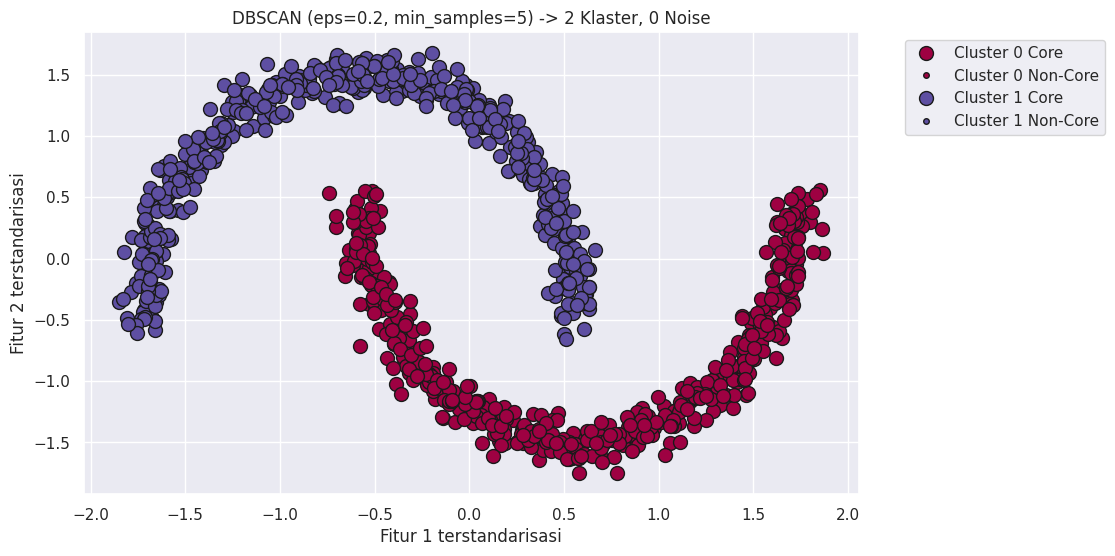

In [72]:
# Visualisasi Hasil DBSCAN
unique_labels_moons = set(labels_moons)
core_samples_mask_moons = np.zeros_like(labels_moons, dtype=bool)
core_samples_mask_moons[db_moons.core_sample_indices_] = True

plt.figure(figsize=(10, 6))
colors_moons = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels_moons))]

for k, col in zip(unique_labels_moons, colors_moons):
    if k == -1:
        # Warna hitam untuk noise
        col = [0, 0, 0, 1]

    class_member_mask = (labels_moons == k)

    # Plot Core Samples (Titik Besar)
    xy_core = X_moons_scaled[class_member_mask & core_samples_mask_moons]
    plt.plot(xy_core[:, 0], xy_core[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10, label=f'Cluster {k} Core' if k != -1 else None)

    # Plot Non-Core Samples (Titik Kecil)
    xy_non_core = X_moons_scaled[class_member_mask & ~core_samples_mask_moons]
    plt.plot(xy_non_core[:, 0], xy_non_core[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=4, label=f'Cluster {k} Non-Core' if k != -1 else 'Noise' if k == -1 else None)

plt.title(f"DBSCAN (eps=0.2, min_samples=5) -> {n_clusters_moons} Klaster, {n_noise_moons} Noise")
plt.xlabel("Fitur 1 terstandarisasi")
plt.ylabel("Fitur 2 terstandarisasi")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

#### **5. Eksperimen Parameter DBSCAN**
Berikut adalah analisis performa DBSCAN dengan berbagai variasi parameter `eps` (0.05, 0.1, 0.3, 0.5) dan `min_samples` (3, 10, 20).

In [73]:
# 5. Eksperimen Parameter
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db_exp = DBSCAN(eps=eps, min_samples=min_samples).fit(X_moons_scaled)
        labels_exp = db_exp.labels_

        n_cl_ = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)
        n_ns_ = list(labels_exp).count(-1)

        # Evaluasi Metrik
        homo = metrics.homogeneity_score(y_moons_true, labels_exp)
        compl = metrics.completeness_score(y_moons_true, labels_exp)
        v_measure = metrics.v_measure_score(y_moons_true, labels_exp)
        ari = metrics.adjusted_rand_score(y_moons_true, labels_exp)
        ami = metrics.adjusted_mutual_info_score(y_moons_true, labels_exp)

        # Koefisien Siluet hanya valid jika terdapat antara 2 hingga N-1 klaster terdeteksi
        if 1 < n_cl_ < len(X_moons_scaled):
            sil = metrics.silhouette_score(X_moons_scaled, labels_exp)
        else:
            sil = np.nan

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Clusters': n_cl_,
            'Noise': n_ns_,
            'Homogeneity': homo,
            'Completeness': compl,
            'V-Measure': v_measure,
            'ARI': ari,
            'AMI': ami,
            'Silhouette': sil
        })

df_results = pd.DataFrame(results)
display(df_results)

,eps,min_samples,Clusters,Noise,Homogeneity,Completeness,V-Measure,ARI,AMI,Silhouette
0,0.05,3,69,186,0.815554,0.152548,0.257021,0.030044,0.243805,0.112929
1,0.05,10,3,970,0.030669,0.126764,0.049389,0.002283,0.045864,-0.294190
2,0.05,20,0,1000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
3,0.10,3,2,14,0.986207,0.902896,0.942714,0.972179,0.942634,0.251690
4,0.10,10,7,57,0.943317,0.409546,0.571132,0.523399,0.569801,0.162306
5,0.10,20,6,850,0.153928,0.155466,0.154693,0.016754,0.150916,-0.360195
6,0.30,3,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391160
7,0.30,10,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391160
8,0.30,20,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391160
9,0.50,3,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391160
